# Hyper Param Analysis

In [1]:
from pathlib import Path
from tqdm.auto import tqdm

import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import cartopy 

from load_tuning_results import (
    load_results_raw,
    load_result_for_key,
    add_derived_features,
    filter_suspicious_routes,
)

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
gdf = gpd.read_parquet("../results/results_prelim.geoparquet")
gdf = add_derived_features(gdf)
gdf

,hyper_population_size,hyper_random_seed,hyper_selection_acceptance_rate_warmup,hyper_mutation_width_fraction_warmup,hyper_mutation_displacement_fraction_warmup,hyper_generations,hyper_offspring_size,hyper_crossover_rounds,hyper_selection_quantile,hyper_selection_acceptance_rate,...,elite_cost_relative,geometry,forcing_scenario_name,forcing_currents_path,forcing_waves_path,forcing_winds_path,hyper_num_individuals,journey_duration,seed_cost,elite_speed_og_mps_average
filename,,,,,,,,,,,,,,,,,,,,,
result:0000:seed3895092605,128,3895092605,0.3,0.99,0.10,2,4,1,0.10,0.00,...,0.880062,"LINESTRING (-11 50, -12.82735 50.10402, -14.69...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,256,11 days 10:10:42,5.926383e+12,6.446294
result:0000:seed3895092605,128,3895092605,0.3,0.99,0.10,2,4,1,0.10,0.00,...,0.880062,"LINESTRING (-11 50, -12.82735 50.10402, -14.69...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,256,11 days 10:10:42,5.926383e+12,6.446294
result:0001:seed1649728346,256,1649728346,0.3,0.99,0.10,4,4,2,0.25,0.00,...,0.017000,"LINESTRING (-11 50, -12.31098 50.04275, -13.47...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,1024,17 days 03:16:03,3.604302e+14,4.551052
result:0001:seed1649728346,256,1649728346,0.3,0.99,0.10,4,4,2,0.25,0.00,...,0.017000,"LINESTRING (-11 50, -12.31098 50.04275, -13.47...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,1024,17 days 03:16:03,3.604302e+14,4.551052
result:0002:seed3030206584,128,3030206584,0.3,0.99,0.25,2,4,1,0.10,0.25,...,0.056787,"LINESTRING (-80.5 30, -79.65597 30.6855, -78.8...",baseline,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,data_large/cmems_obs-wind_glo_phy_my_l4_0.125d...,256,13 days 17:00:51,7.524805e+13,5.326478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
result:3997:seed3352588423,64,3352588423,0.3,0.99,0.25,1,4,1,0.25,0.25,...,0.995504,"LINESTRING (-80.5 30, -79.82039 30.53534, -79....",no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,64,17 days 03:16:03,1.424118e+13,4.115572
result:3998:seed2264517074,128,2264517074,0.3,0.99,0.10,1,4,0,0.10,0.00,...,0.975562,"LINESTRING (-11 50, -12.8399 50.12425, -14.687...",no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,128,11 days 10:10:42,6.351398e+12,6.186218
result:3998:seed2264517074,128,2264517074,0.3,0.99,0.10,1,4,0,0.10,0.00,...,0.975562,"LINESTRING (-11 50, -12.8399 50.12425, -14.687...",no_winds,data_large/cmems_mod_glo_phy_my_0.083deg_P1D-m...,data_large/cmems_mod_glo_wav_my_0.2deg_PT3H-i_...,NaN,128,11 days 10:10:42,6.351398e+12,6.186218


In [4]:
gdf = filter_suspicious_routes(gdf)

0.35% suspicious routes


In [5]:
gdf.columns

Index(['hyper_population_size', 'hyper_random_seed',
       'hyper_selection_acceptance_rate_warmup',
       'hyper_mutation_width_fraction_warmup',
       'hyper_mutation_displacement_fraction_warmup', 'hyper_generations',
       'hyper_offspring_size', 'hyper_crossover_rounds',
       'hyper_selection_quantile', 'hyper_selection_acceptance_rate',
       'hyper_mutation_width_fraction', 'hyper_mutation_displacement_fraction',
       'hyper_mutation_iterations', 'hyper_crossover_strategy',
       'hyper_hazard_penalty_multiplier', 'hyper_num_elites',
       'hyper_gd_iterations', 'hyper_learning_rate_time',
       'hyper_learning_rate_space', 'hyper_time_increment',
       'hyper_distance_increment', 'hyper_enable_adaptation',
       'hyper_target_relative_improvement', 'hyper_adaptation_scale_W',
       'hyper_adaptation_scale_D', 'hyper_W_min', 'hyper_W_max', 'hyper_D_min',
       'hyper_D_max', 'hyper_num_workers', 'hyper_executor_type',
       'journey_name', 'journey_lon_waypoints

## Add effective mutation step size

In [6]:
gdf = gdf.assign(
    effective_mutation_step_size=(
        0.5  # normlized Hann window area
        * (gdf.hyper_mutation_width_fraction + gdf.hyper_W_min) / 2.0  # mean W
        * (gdf.hyper_mutation_displacement_fraction + gdf.hyper_D_min) / 2.0  # mean D
        * (gdf.hyper_mutation_iterations + 1) / 2.0  # mean Nmut
    ),
    mu_plus_lambda=(
        gdf.hyper_population_size + gdf.hyper_crossover_rounds * gdf.hyper_offspring_size
    ),
    mu_plus_lambda_q=gdf.hyper_selection_quantile * (
        gdf.hyper_population_size + gdf.hyper_crossover_rounds * gdf.hyper_offspring_size
    ),
)
gdf = gdf.assign(
    effective_mutation_step_size_pop_gen=gdf.effective_mutation_step_size * (
        gdf.hyper_population_size * gdf.hyper_generations
    )
)

## Influence of population size, crossover rounds, and mutation iterations

In [8]:
def plot_elite_cost_hyper_params(
    gdf: gpd.GeoDataFrame = None,
    forcing_scenario_name: str = "baseline",
    secondary_legend: str = "hyper_crossover_rounds",
    relabs: str = "relative",
    hyper_hazard_penalty_multiplier: float = 0,
):
    _gdf = gdf.where(
        (gdf.hyper_hazard_penalty_multiplier == hyper_hazard_penalty_multiplier)
        & (gdf.forcing_scenario_name == forcing_scenario_name)
    ).dropna(how="all")
    _gdf["journey_cat"] = (
        _gdf["journey_name"].astype(str)
        + " | " + _gdf["journey_speed_knots"].astype(str) + " kn"
        + " | " + pd.to_datetime(_gdf["journey_time_start"]).dt.strftime("%Y-%m")
    ).astype('category')
    _q_gdf = (
        _gdf.groupby(["effective_mutation_step_size_pop_gen", secondary_legend, "journey_name", "journey_speed_knots"])[f"elite_cost_{relabs}"]
        .quantile(np.linspace(0, 1, 31))
        .reset_index()
        .rename(columns={"level_4": "quantile", f"elite_cost_{relabs}": "value"})
    )
    sns.set_style("whitegrid")
    g = sns.relplot(
        data=_q_gdf,
        kind="line",
        x="quantile",
        y="value",
        style="journey_speed_knots",
        row="journey_name",
        hue="effective_mutation_step_size_pop_gen",
        col=secondary_legend,
        marker="",
        height=3,
        aspect=1.5,
        linewidth=2,
        facet_kws={"sharey": True, "margin_titles": True},
    )
    g.set_axis_labels("Quantile", f"Elite cost ({relabs})")
    g.set_titles(col_template=f"{forcing_scenario_name}: population size: {{col_name}}", row_template="{row_name}")
    # g.fig.savefig(f"../figures/03_hyper_cost_distribution_{secondary_legend}_{relabs}_scen-{forcing_scenario_name}.png", dpi=200)
    # g.fig.savefig(f"../figures/03_hyper_cost_distribution_{secondary_legend}_{relabs}_scen-{forcing_scenario_name}.pdf", dpi=200)
    return g.fig

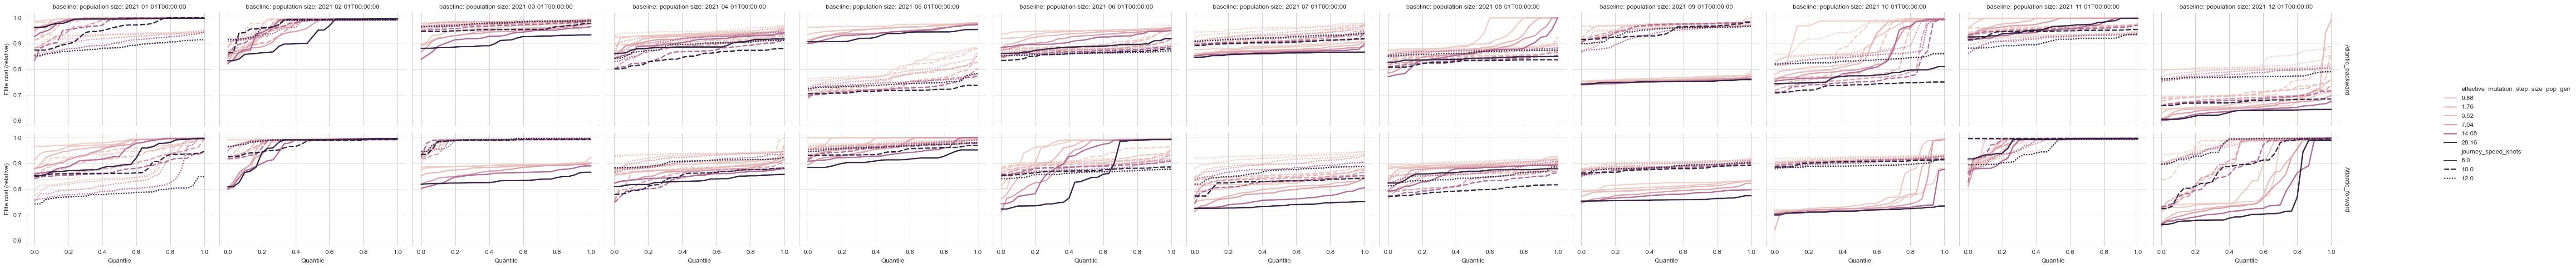

In [11]:
for fsn in ["baseline"]:  # gdf.forcing_scenario_name.unique():
    for relabs in ["relative"]:  # ["absolute", "relative"]:
        for sl in ["journey_time_start"]:   #, "hyper_crossover_rounds", "hyper_mutation_iterations"]:
            plot_elite_cost_hyper_params(gdf=gdf, relabs=relabs, forcing_scenario_name=fsn, secondary_legend=sl);

In [ ]:
def plot_elite_cost_hyper_params_scatter(
    gdf: gpd.GeoDataFrame = None,
    forcing_scenario_name: str = "baseline",
    secondary_legend: str = "hyper_crossover_rounds",
    relabs: str = "relative",
    hyper_hazard_penalty_multiplier: float = 0,
    quantile: float = 0.1,
):
    """
    Plot scatter plot of elite costs at a specific quantile (default 10%).
    
    Parameters
    ----------
    gdf : gpd.GeoDataFrame
        GeoDataFrame with tuning results
    forcing_scenario_name : str
        Forcing scenario to filter by
    secondary_legend : str
        Hyperparameter column to use for marker style
    relabs : str
        'relative' or 'absolute' cost
    hyper_hazard_penalty_multiplier : float
        Hazard penalty multiplier to filter by
    quantile : float
        Quantile to compute (default 0.1 for 10th percentile)
    
    Returns
    -------
    matplotlib.figure.Figure
        The generated figure
    """
    _gdf = gdf.where(
        (gdf.hyper_hazard_penalty_multiplier == hyper_hazard_penalty_multiplier)
        & (gdf.forcing_scenario_name == forcing_scenario_name)
    ).dropna(how="all")
    
    _gdf["journey_month"] = pd.to_datetime(_gdf["journey_time_start"]).dt.strftime("%Y-%m")
    
    _q_gdf = (
        _gdf.groupby([
            "hyper_population_size",
            secondary_legend,
            "journey_name",
            "journey_speed_knots",
            "journey_month"
        ])[f"elite_cost_{relabs}"]
        .quantile(quantile)
        .reset_index()
        .rename(columns={f"elite_cost_{relabs}": f"elite_cost_{relabs}_q"})
    )
    
    sns.set_style("whitegrid")
    g = sns.relplot(
        data=_q_gdf,
        kind="scatter",
        x="journey_month",
        y=f"elite_cost_{relabs}_q",
        hue="journey_speed_knots",
        style=secondary_legend,
        col="hyper_population_size",
        row="journey_name",
        s=100,
        alpha=0.6,
        height=3,
        aspect=1.5,
        palette="Dark2",
        edgecolor="darkgray",
        markers=['o', 's', '*'],
        facet_kws={"sharey": True, "margin_titles": True},
    )
    
    g.set_axis_labels("Month", f"Elite cost ({relabs}) - {quantile*100:.0f}% quantile")
    g.set_titles(col_template=f"{forcing_scenario_name}: population size: {{col_name}}", row_template="{row_name}")
    
    # Rotate x-axis labels for readability
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)
    
    # Move legend to bottom
    # g.fig.subplots_adjust(bottom=0.15)
    # if g._legend is not None:
    #     g._legend.remove()
    # g.add_legend(bbox_to_anchor=(0.5, -0.05), loc='upper center', ncol=6)
    
    g.fig.savefig(f"../figures/03_hyper_cost_scatter_{secondary_legend}_{relabs}_scen-{forcing_scenario_name}.png", dpi=200, bbox_inches='tight')
    g.fig.savefig(f"../figures/03_hyper_cost_scatter_{secondary_legend}_{relabs}_scen-{forcing_scenario_name}.pdf", dpi=200, bbox_inches='tight')
    
    return g.fig

In [ ]:
# Example usage: Generate scatter plots for different hyperparameters
for fsn in ["baseline"]:  # gdf.forcing_scenario_name.unique():
    for relabs in ["relative"]:  # ["absolute", "relative"]:
        for sl in ["hyper_generations", "hyper_crossover_rounds", "hyper_mutation_iterations"]:
            plot_elite_cost_hyper_params_scatter(gdf=gdf, relabs=relabs, forcing_scenario_name=fsn, secondary_legend=sl, quantile=0.25);

In [ ]:
def plot_elite_cost_hyper_params_count(
    gdf: gpd.GeoDataFrame = None,
    forcing_scenario_name: str = "baseline",
    secondary_legend: str = "hyper_crossover_rounds",
    hyper_hazard_penalty_multiplier: float = 0,
):
    """
    Plot count of observations per group.
    
    Parameters
    ----------
    gdf : gpd.GeoDataFrame
        GeoDataFrame with tuning results
    forcing_scenario_name : str
        Forcing scenario to filter by
    secondary_legend : str
        Hyperparameter column to use for marker style
    hyper_hazard_penalty_multiplier : float
        Hazard penalty multiplier to filter by
    
    Returns
    -------
    matplotlib.figure.Figure
        The generated figure
    """
    _gdf = gdf.where(
        (gdf.hyper_hazard_penalty_multiplier == hyper_hazard_penalty_multiplier)
        & (gdf.forcing_scenario_name == forcing_scenario_name)
    ).dropna(how="all")
    
    _gdf["journey_month"] = pd.to_datetime(_gdf["journey_time_start"]).dt.strftime("%Y-%m")
    
    _count_gdf = (
        _gdf.groupby([
            "hyper_population_size",
            secondary_legend,
            "journey_name",
            "journey_speed_knots",
            "journey_month"
        ])
        .size()
        .reset_index(name="count")
    )
    
    sns.set_style("whitegrid")
    g = sns.relplot(
        data=_count_gdf,
        kind="scatter",
        x="journey_month",
        y="count",
        hue="journey_speed_knots",
        style=secondary_legend,
        col="hyper_population_size",
        row="journey_name",
        s=100,
        alpha=0.7,
        height=3,
        aspect=1.5,
        palette="Set2",
        markers=['o', 's', '*'],
        facet_kws={"sharey": True, "margin_titles": True},
    )
    
    g.set_axis_labels("Month", "Count of observations")
    g.set_titles(col_template=f"{forcing_scenario_name}: population size: {{col_name}}", row_template="{row_name}")
    
    # Rotate x-axis labels for readability
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=45)
    
    g.fig.savefig(f"../figures/03_hyper_count_{secondary_legend}_scen-{forcing_scenario_name}.png", dpi=200, bbox_inches='tight')
    g.fig.savefig(f"../figures/03_hyper_count_{secondary_legend}_scen-{forcing_scenario_name}.pdf", dpi=200, bbox_inches='tight')
    
    return g.fig

In [ ]:
# Example usage: Generate count plots for different hyperparameters
for fsn in ["baseline"]:
    for sl in ["hyper_generations", "hyper_crossover_rounds", "hyper_mutation_iterations"]:
        plot_elite_cost_hyper_params_count(gdf=gdf, forcing_scenario_name=fsn, secondary_legend=sl);